Дорогой студент!

В домашнем задании Lite вам предлагается поработать подробнее с параметрами словаря и формированием гиперпараметров нейронной сети. Создайте 9 нейросетей с различными гиперпараметрами (см. пунтк 2 и 3)

 Для этого необходимо:

  1. Воссоздать ноутбук, аналогичный ноутбуку практической части №1, загрузив при этом необходимую нам базу (код уже доступен в ноутбуке).

  2. Задать в ноутбуке следующие параметры для размера словаря, ширины окна и шага:

    - Размер словаря - от 10000 до 20000 (выбрать меньшее значение диапазона, если будет перегрузка ОЗУ и перезапуск подключения к Colaboratory)
    - Ширина окна - от 1000 до 2000
    - Шаг - от 100 до 500 (на обучение лучше влияет наименьший шаг, но это может перегрузить ОЗУ).

  3. Создать архитектуру сети и задать гиперпараметры. Можно воспользоваться шаблоном:
  
   - Добавьте модель прямого распространения **Sequential()**
   - Добавьте один или несколько полносвязных (**Dense**) слоёв
   - Добавьте слои **Dropout()** и **BatchNormalization()**
   - Добавьте выходной полносвязный слой с количеством нейронов, соответствующим количеству классов (число писателей)
  
   Напомним, что точность сети можно проверить по значению показателя 'val_accuracy' на конце каждой эпохи.
   

## Подключение необходимых библиотек 

In [1]:
# Работа с массивами данных
import numpy as np

import tensorflow as tf

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасетов из облака google
import gdown

# Функции операционной системы
import os

# Работа со временем
import time

# Регулярные выражения
import re

# Запись в файлы и чтение из файлов структур данных Python
import pickle

# Отрисовка графиков
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)

'writers.zip'

In [3]:
# Распаковка архива в папку writers
!unzip -qo writers.zip -d writers/

# Просмотр содержимого папки
!ls writers

'(Булгаков) Обучающая_5 вместе.txt'
'(Булгаков) Тестовая_2 вместе.txt'
'(Клиффорд_Саймак) Обучающая_5 вместе.txt'
'(Клиффорд_Саймак) Тестовая_2 вместе.txt'
'(Макс Фрай) Обучающая_5 вместе.txt'
'(Макс Фрай) Тестовая_2 вместе.txt'
'(О. Генри) Обучающая_50 вместе.txt'
'(О. Генри) Тестовая_20 вместе.txt'
'(Рэй Брэдберри) Обучающая_22 вместе.txt'
'(Рэй Брэдберри) Тестовая_8 вместе.txt'
'(Стругацкие) Обучающая_5 вместе.txt'
'(Стругацкие) Тестовая_2 вместе.txt'


In [4]:
# Настройка констант для загрузки данных
FILE_DIR  = 'writers'                     # Папка с текстовыми файлами
SIG_TRAIN = 'обучающая'                   # Признак обучающей выборки в имени файла
SIG_TEST  = 'тестовая'                    # Признак тестовой выборки в имени файла

In [7]:
# Загрузка датасета. Добавляются имена классов и соответствующие тексты.
# Все тексты преобразуются в строку и объединяются для каждого класса и выборки
CLASS_LIST = []
text_train = []
text_test = []

for file_name in os.listdir(FILE_DIR):
    # Выделение имени класса и типа выборки из имени файла
    m = re.match(r'\((.+)\) (\S+)_', file_name)
    # Если выделение получилось, то файл обрабатывается
    if m:
        class_name = m[1]
        subset_name = m[2].lower()
        # Проверка типа выборки в имени файла
        is_train = SIG_TRAIN in subset_name
        is_test = SIG_TEST in subset_name

        # Если тип выборки обучающая либо тестовая - файл обрабатывается
        if is_train or is_test:
            # Добавление нового класса, если его еще нет в списке
            if class_name not in CLASS_LIST:
                print(f'Добавление класса "{class_name}"')
                CLASS_LIST.append(class_name)
                # Инициализация соответствующих классу строк текста
                text_train.append('')
                text_test.append('')

            # Поиск индекса класса для добавления содержимого файла в выборку
            cls = CLASS_LIST.index(class_name)
            print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}", {subset_name} выборка.')
            with open(f'{FILE_DIR}/{file_name}', 'r') as f:
                # Загрузка содержимого файла в строку
                text = f.read()
            # Определение выборки, куда будет добавлено содержимое
            subset = text_train if is_train else text_test
            # Добавление текста к соответствующей выборке класса. Концы строк заменяются на пробел
            subset[cls] += ' ' + text.replace('\n', ' ')

# Определение количества классов
CLASS_COUNT = len(CLASS_LIST)

Добавление класса "О. Генри"
Добавление файла "(О. Генри) Тестовая_20 вместе.txt" в класс "О. Генри", тестовая выборка.
Добавление класса "Рэй Брэдберри"
Добавление файла "(Рэй Брэдберри) Обучающая_22 вместе.txt" в класс "Рэй Брэдберри", обучающая выборка.
Добавление класса "Булгаков"
Добавление файла "(Булгаков) Обучающая_5 вместе.txt" в класс "Булгаков", обучающая выборка.
Добавление класса "Клиффорд_Саймак"
Добавление файла "(Клиффорд_Саймак) Тестовая_2 вместе.txt" в класс "Клиффорд_Саймак", тестовая выборка.
Добавление файла "(Булгаков) Тестовая_2 вместе.txt" в класс "Булгаков", тестовая выборка.
Добавление класса "Макс Фрай"
Добавление файла "(Макс Фрай) Тестовая_2 вместе.txt" в класс "Макс Фрай", тестовая выборка.
Добавление класса "Стругацкие"
Добавление файла "(Стругацкие) Обучающая_5 вместе.txt" в класс "Стругацкие", обучающая выборка.
Добавление файла "(О. Генри) Обучающая_50 вместе.txt" в класс "О. Генри", обучающая выборка.
Добавление файла "(Рэй Брэдберри) Тестовая_8 вмест

In [8]:
# Прочитанные классы текстов
print(CLASS_LIST)

# Количество текстов в обучающей выборке
print(len(text_train))

# Количество символов в одном из текстов обучающей выборки
print(len(text_train[3]))

['О. Генри', 'Рэй Брэдберри', 'Булгаков', 'Клиффорд_Саймак', 'Макс Фрай', 'Стругацкие']
6
1609508


In [21]:
# Задание параметров преобразования
VOCAB_SIZE = 5000                        # Объем словаря для токенизатора
WIN_SIZE   = 500                         # Длина отрезка текста (окна) в словах
WIN_HOP    = 50                         # Шаг окна разбиения текста на векторы

In [22]:
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE, 
    filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
    lower=True, split=' ', 
    oov_token='неизвестное_слово', 
    char_level=False)

tokenizer.fit_on_texts(text_train)
items = list(tokenizer.word_index.items())

print(f"Первые 10 элементов словаря: {items[:10]}")

Первые 10 элементов словаря: [('неизвестное_слово', 1), ('и', 2), ('в', 3), ('не', 4), ('я', 5), ('что', 6), ('на', 7), ('с', 8), ('он', 9), ('а', 10)]


In [23]:
train_seq = tokenizer.texts_to_sequences(text_train)
test_seq = tokenizer.texts_to_sequences(text_test)

print(f"Первые 10 слов в виде оригинального текста: {text_train[0][:68]}")
print(f"Первые 10 слов из первого текста обучающей выборки: {train_seq[0][:10]}")
print(f"Первые 10 слов в виде оригинального текста: {text_test[0][:69]}")
print(f"Первые 10 слов из первого текста тестовой выборки: {test_seq[0][:10]}")

Первые 10 слов в виде оригинального текста:  «Лиса-на-рассвете»   Коралио нежился в полуденном зное, как томная 
Первые 10 слов из первого текста обучающей выборки: [4725, 7, 2449, 1757, 1, 3, 1, 1, 11, 1]
Первые 10 слов в виде оригинального текста:  ﻿Багдадская птица   Без всякого сомнения, дух и гений калифа Гаруна 
Первые 10 слов из первого текста тестовой выборки: [1, 1501, 99, 1152, 1972, 1146, 2, 4039, 1, 1]


In [24]:
def print_text_stats(title: str, texts: list, sequences: list, class_labels: list = CLASS_LIST) -> None:
    # Суммарное количество символов и слов в тексте
    chars = 0
    words = 0

    print(f'Статистика по {title} текстам:')

    # Вывод итогов по всем классам данного набора текстов и их последовательностей индексов
    for cls in range(len(class_labels)):
        print('{:<15} {:9} символов,{:8} слов'.format(class_labels[cls],
                                                      len(texts[cls]),
                                                      len(sequences[cls])))
        chars += len(texts[cls])
        words += len(sequences[cls])

    print('----')
    print('{:<15} {:9} символов,{:8} слов\n'.format('В сумме', chars, words))

# Вывод итогов по текстам
print_text_stats('обучающим', text_train, train_seq)
print_text_stats('тестовым', text_test, test_seq)

Статистика по обучающим текстам:
О. Генри          1049518 символов,  160607 слов
Рэй Брэдберри     1386455 символов,  214454 слов
Булгаков          1765649 символов,  261465 слов
Клиффорд_Саймак   1609508 символов,  251502 слов
Макс Фрай         3700011 символов,  568533 слов
Стругацкие        2042470 символов,  313012 слов
----
В сумме          11553611 символов, 1769573 слов

Статистика по тестовым текстам:
О. Генри           349663 символов,   53238 слов
Рэй Брэдберри      868674 символов,  132524 слов
Булгаков           875043 символов,  132730 слов
Клиффорд_Саймак    318812 символов,   50360 слов
Макс Фрай         1278192 символов,  196731 слов
Стругацкие         704847 символов,  108621 слов
----
В сумме           4395231 символов,  674204 слов



In [25]:
def split_sequences(sequence: list, win_size: int = WIN_SIZE, win_hop: int = WIN_HOP) -> list:

    n = len(sequence)
    windows = []

    for i in range(0, n - win_size + 1, win_hop):
        window = sequence[i:i + win_size]
        windows.append(window)
    
    return windows

In [26]:
print(split_sequences(train_seq[0])[:2])

[[4725, 7, 2449, 1757, 1, 3, 1, 1, 11, 1, 1, 3, 3274, 1, 1, 272, 1057, 16, 259, 2150, 7, 1, 1, 644, 9, 2552, 1, 1, 3, 1652, 1, 1, 952, 11, 27, 55, 1, 133, 130, 1, 122, 1409, 3211, 1, 907, 1, 1158, 1, 1, 36, 193, 1, 63, 1, 2609, 4726, 1, 953, 1, 1891, 1, 2927, 3, 1, 1, 2, 1, 1, 1, 221, 1, 1, 11, 1, 1, 145, 721, 1, 1, 1, 593, 272, 1, 2, 1, 1934, 1, 1, 17, 1, 1, 371, 1, 78, 15, 1460, 1, 1, 1, 1200, 7, 1, 1, 1, 1, 1, 1, 1, 1, 50, 64, 1, 1, 2656, 246, 272, 4242, 80, 2414, 1, 4, 743, 3362, 3, 1757, 4243, 4727, 8, 1, 1, 1, 1310, 1, 2121, 1, 917, 281, 1, 1, 336, 1, 221, 1, 17, 1, 144, 1, 886, 8, 1, 1, 1, 4861, 31, 4591, 1, 2, 1, 1217, 1, 1, 3824, 7, 1, 2, 1, 1, 2, 2553, 1, 1, 1, 1, 1200, 1, 294, 1855, 1, 1, 1, 1, 138, 43, 1, 1, 1, 2, 3212, 6, 1200, 7, 960, 1, 8, 1, 961, 1, 2, 4862, 3, 179, 1, 1, 4244, 1, 1829, 6, 1855, 1200, 324, 12, 3506, 880, 1, 1, 95, 3, 1291, 1, 40, 3, 1636, 2342, 1, 1, 703, 1520, 105, 2, 4343, 7, 537, 133, 1244, 95, 1, 8, 1, 1935, 2, 4592, 160, 1, 613, 72, 1, 7, 144, 1, 1

In [27]:
def vectorize_sequences(sequences: list, win_size: int = WIN_SIZE, win_hop: int = WIN_HOP) -> np.ndarray:

    class_count = len(sequences)

    x, y = [], []

    for cls in range(class_count):

        vectors = split_sequences(sequences[cls], win_size, win_hop)

        x.extend(vectors)

        y.extend([cls] * len(vectors))
    return np.array(x), np.array(y)

In [28]:
x_train, y_train = vectorize_sequences(train_seq)
x_test, y_test = vectorize_sequences(test_seq)

print(f'Размер обучающей выборки: {x_train.shape}, {y_train.shape}')
print(f'Размер тестовой выборки: {x_test.shape}, {y_test.shape}')

Размер обучающей выборки: (35336, 500), (35336,)
Размер тестовой выборки: (13427, 500), (13427,)


In [29]:
print(f"{x_train[0][:10]} - первые 10 слов из первого вектора обучающей выборки")
print(f"{y_train[0]} - класс первого вектора обучающей выборки")

[4725    7 2449 1757    1    3    1    1   11    1] - первые 10 слов из первого вектора обучающей выборки
0 - класс первого вектора обучающей выборки


In [30]:
x_train_01 = tokenizer.sequences_to_matrix(x_train.tolist())
x_test_01 = tokenizer.sequences_to_matrix(x_test.tolist())

# Вывод формы обучающей выборки в виде разреженной матрицы Bag of Words
print(x_train_01.shape)
# Вывод фрагмента отрезка обучающего текста в виде Bag of Words
print(x_train_01[0][0:100])

(35336, 5000)
[0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1.
 0. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 1. 1. 0. 1. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0.
 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1.
 0. 0. 1. 0.]


In [31]:
# Функция компиляции и обучения модели нейронной сети
def compile_train_model(model,
                        x_train,
                        y_train,
                        x_val,
                        y_val,
                        optimizer='adam',
                        epochs=50,
                        batch_size=128,
                        figsize=(20, 5)):
    
    callback = tf.keras.callbacks.EarlyStopping(
                    monitor='val_loss',
                    mode='min', min_delta=0.001,
                    patience = 5,
                    restore_best_weights=True 
                    )


    # Компиляция модели
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy']
                 )

    # Вывод сводки
    model.summary()

    # Обучение модели с заданными параметрами
    history = model.fit(x_train,
                        y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(x_val, y_val),
                        callbacks=[callback])

    # Вывод графиков точности и ошибки
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('График процесса обучения модели')
    ax1.plot(history.history['accuracy'],
               label='Доля верных ответов на обучающем наборе')
    ax1.plot(history.history['val_accuracy'],
               label='Доля верных ответов на проверочном наборе')
    ax1.xaxis.get_major_locator().set_params(integer=True)
    ax1.set_xlabel('Эпоха обучения')
    ax1.set_ylabel('Доля верных ответов')
    ax1.legend()

    ax2.plot(history.history['loss'],
               label='Ошибка на обучающем наборе')
    ax2.plot(history.history['val_loss'],
               label='Ошибка на проверочном наборе')
    ax2.xaxis.get_major_locator().set_params(integer=True)
    ax2.set_xlabel('Эпоха обучения')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()


# Функция вывода результатов оценки модели на заданных данных
def eval_model(model, x, y_true, class_labels=[], title='', figsize=(10, 10)):

    y_pred = model.predict(x)

    y_pred_cls = np.argmax(y_pred, axis=1) 
    y_true_cls = y_true  
    acc = (y_pred_cls == y_true_cls).mean()

    
    cm = confusion_matrix(y_true_cls, y_pred_cls, normalize='true')

    cm_rounded = np.around(cm, 3)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(f'Confusion Matrix: {title}', fontsize=16)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_rounded,
        display_labels=class_labels
    )

    disp.plot(ax=ax, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    print('-' * 80)
    print(f'Accuracy: {acc:.4f}')

    # правильная интерпретация
    for i in range(len(class_labels)):
        predicted_class = np.argmax(cm[i])
        status = "OK" if predicted_class == i else "ERROR"

        print(f"{class_labels[i]:<20} → {class_labels[predicted_class]:<20} | {status}")

    print(f"\nMean class accuracy: {np.mean(np.diag(cm)):.4f}")


# Совместная функция обучения и оценки модели нейронной сети
def compile_train_eval_model(model,
                             x_train,
                             y_train,
                             x_test,
                             y_test,
                             class_labels=CLASS_LIST,
                             title='',
                             optimizer='adam',
                             epochs=50,
                             batch_size=128,
                             graph_size=(20, 5),
                             cm_size=(10, 10)):

    # Компиляция и обучение модели на заданных параметрах
    # В качестве проверочных используются тестовые данные
    compile_train_model(model,
                        x_train, y_train,
                        x_test, y_test,
                        optimizer=optimizer,
                        epochs=epochs,
                        batch_size=batch_size,
                        figsize=graph_size)

    # Вывод результатов оценки работы модели на тестовых данных
    eval_model(model, x_test, y_test,
               class_labels=class_labels,
               title=title,
               figsize=cm_size)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 100)            │       500,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 501,106 (1.91 MB)

 Trainable params: 500,906 (1.91 MB)

 Non-trainable params: 200 (800.00 B)

Epoch 1/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9748 - loss: 0.0924 - val_accuracy: 0.8169 - val_loss: 0.5377
Epoch 2/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.8219 - val_loss: 0.5117
Epoch 3/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.8159 - val_loss: 0.5313
Epoch 4/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 7.0909e-04 - val_accuracy: 0.8184 - val_loss: 0.5267
Epoch 5/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 4.1447e-04 - val_accuracy: 0.8175 - val_loss: 0.5313
Epoch 6/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 2.7545e-04 - val_accuracy: 0.8184 - val_loss: 0.5381
Epoch 7/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 3.0898e-04 - val_accuracy: 0.8150 - val_loss: 0.5359


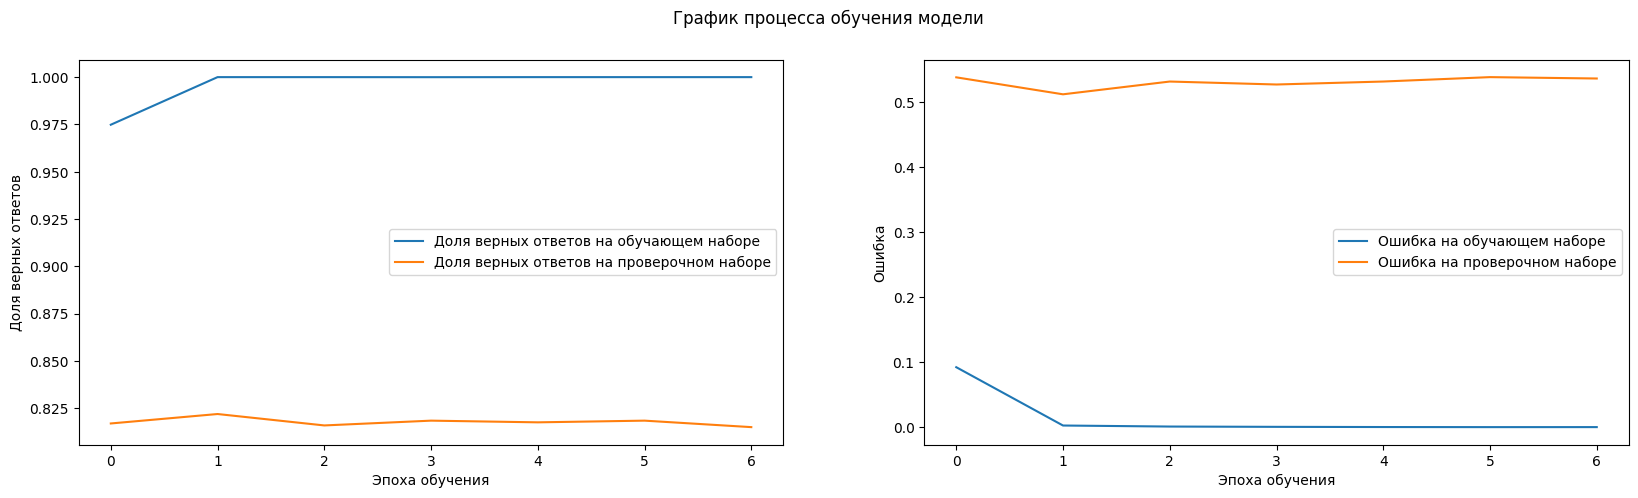

420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


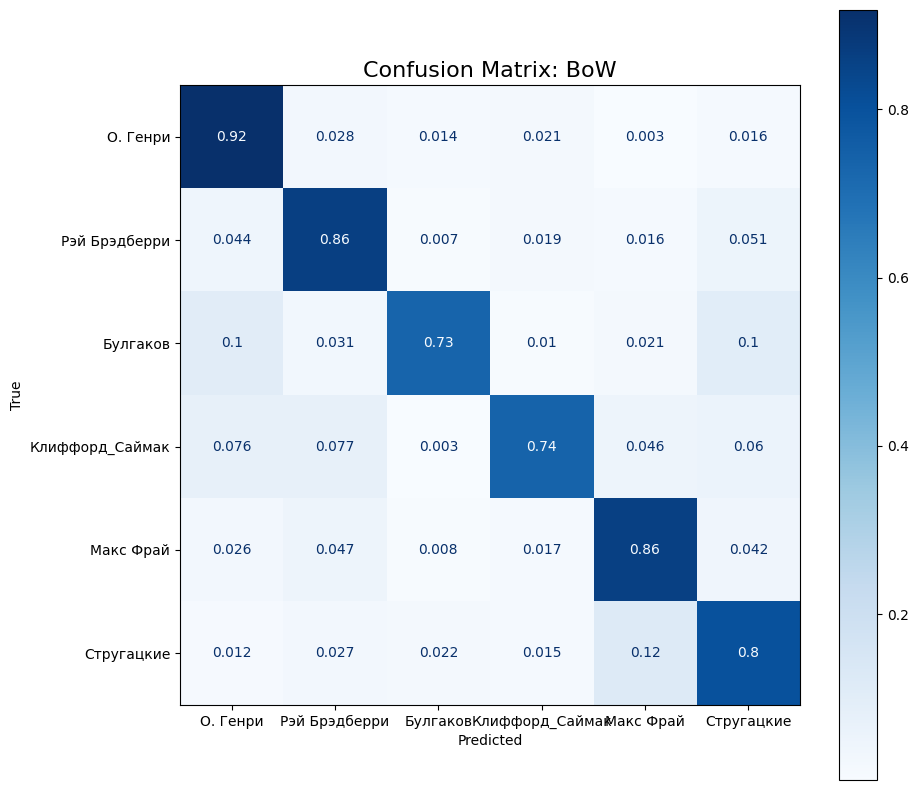

--------------------------------------------------------------------------------
Accuracy: 0.8219
О. Генри             → О. Генри             | OK
Рэй Брэдберри        → Рэй Брэдберри        | OK
Булгаков             → Булгаков             | OK
Клиффорд_Саймак      → Клиффорд_Саймак      | OK
Макс Фрай            → Макс Фрай            | OK
Стругацкие           → Стругацкие           | OK

Mean class accuracy: 0.8191


In [32]:
model_text_bow_softmax = Sequential()
model_text_bow_softmax.add(Dense(100, input_dim=VOCAB_SIZE, activation="relu"))
model_text_bow_softmax.add(Dropout(0.25))
model_text_bow_softmax.add(BatchNormalization())
model_text_bow_softmax.add(Dense(CLASS_COUNT, activation='softmax'))


compile_train_eval_model(model_text_bow_softmax,
                         x_train_01, y_train,
                         x_test_01, y_test,
                         class_labels=CLASS_LIST,
                         title='BoW')